In [1]:
import os
from pathlib import Path
REPO = Path.cwd().resolve().parents[1]          # docs/notebooks -> repo root
GOLDEN = Path(os.environ.get("CAL_DISP_GOLDEN_DIR", REPO / "test_golden"))
SCRATCH = Path(os.environ.get("TMPDIR", REPO / "tmp")) / "cal_disp_notebooks"; SCRATCH.mkdir(parents=True, exist_ok=True)

import time

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import rioxarray  # noqa: F401  (registers the .rio accessor)
import xarray as xr

from cal_disp.product import DispProduct, StaticLayer, TropoProduct, compute_los_correction, interpolate_to_dem_surface

plt.rcParams["figure.dpi"] = 90
print("repo:", REPO)
print("golden:", GOLDEN, GOLDEN.exists())

/u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp/.pixi/envs/dev/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo: /u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp
golden: /u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp/test_golden True


# 02 — Tropospheric delay was quantised to float16 (~2 mm steps)

**Defect** (line numbers at commit `dcce716`, the state before the fix). The DISP-S1-STATIC DEM GeoTIFF is
stored as **float16**. `StaticLayer.read` / `StaticLayer.to_dataset` (`src/cal_disp/product/_static.py:177-180`)
kept that dtype, and `interpolate_to_dem_surface` (`src/cal_disp/product/_tropo.py:464-465`) built its output as
`out = dem.copy(); out.values[:] = vals...astype(np.float32)` - i.e. the interpolated zenith delay (about
2.4 m) was written **into a float16 buffer**. float16 has a 10-bit mantissa, so between 2 and 4 m the
spacing of representable values is 2⁻⁹ m = **1.95 mm**: the whole-frame delay collapsed onto a few dozen
distinct values. After projection to the line of sight (`/ los_up`) and differencing (secondary − reference)
this became ±2-3 mm terracing that was added back into the `calibration` layer.

**Fix.** float16 rasters are promoted to float32 as soon as they are read (`StaticLayer.read`,
`read_bands`, hence `to_dataset`), and `interpolate_to_dem_surface` builds a new float32 array
(`dem.astype(np.float32, copy=True)`) instead of writing into the DEM buffer.

**This notebook** loads the golden DEM (shows its dtype), interpolates the reference-date zenith delay onto
the DEM the fixed way and the old way (simulated by casting the DEM/result to float16), and reports the
number of unique values, the step size, a histogram of the differences and an image of the terracing.
Rasters are decimated 4x for speed and notebook size (the quantisation is per pixel, so this changes
nothing about the effect).

In [2]:
static_dir = GOLDEN / "input_data" / "static_input"
dem_file = next(static_dir.glob("*_dem.tif"))
los_file = next(static_dir.glob("*_line_of_sight_enu.tif"))
with rasterio.open(dem_file) as src:
    print(f"{dem_file.name}\n  on-disk dtype: {src.dtypes[0]}, shape {src.shape}, nodata {src.nodata}")
with rasterio.open(los_file) as src:
    print(f"{los_file.name}\n  on-disk dtype: {src.dtypes}")

DEC = 4
dem_ds = StaticLayer.from_path(dem_file).to_dataset()
dem_ds = dem_ds.rio.write_crs(dem_ds.attrs["crs_wkt"])
dem32 = dem_ds["dem"].isel(y=slice(None, None, DEC), x=slice(None, None, DEC))
print(f"\nStaticLayer.to_dataset() dtype after the fix: {dem32.dtype}  (decimated to {dem32.shape})")
hmin, hmax = float(np.nanmin(dem32.values)), float(np.nanmax(dem32.values))
print(f"DEM heights {hmin:.1f} to {hmax:.1f} m; the promotion is exact (float16 -> float32 loses nothing):"
      f" {np.array_equal(dem32.values, dem32.values.astype(np.float16).astype(np.float32))}")
for value in (hmax, 2.4):
    print(f"  float16 spacing at {value:g}: {float(np.spacing(np.float16(value))) * 1e3:.3f} mm"
          f"   (float32: {float(np.spacing(np.float32(value))) * 1e3:.6f} mm)")

OPERA_L3_DISP-S1-STATIC_F08882_20140403_S1A_v1.0_dem.tif
  on-disk dtype: float16, shape (7733, 9464), nodata None
OPERA_L3_DISP-S1-STATIC_F08882_20140403_S1A_v1.0_line_of_sight_enu.tif
  on-disk dtype: ('float32', 'float32', 'float32')



StaticLayer.to_dataset() dtype after the fix: float32  (decimated to (1934, 2366))
DEM heights -40.2 to 201.2 m; the promotion is exact (float16 -> float32 loses nothing): True
  float16 spacing at 201.25: 125.000 mm   (float32: 0.015259 mm)
  float16 spacing at 2.4: 1.953 mm   (float32: 0.000238 mm)


In [3]:
disp_file = next((GOLDEN / "input_data" / "disp").glob("OPERA_L3_DISP-S1_*.nc"))
disp_product = DispProduct.from_path(disp_file)
ref_date = disp_product.reference_date
tropo_file = next((GOLDEN / "input_data" / "tropo").glob(f"OPERA_L4_TROPO-ZENITH_{ref_date:%Y%m%d}T*.nc"))
bounds = list(disp_product.get_bounds_wgs84().values())
max_height = float(dem32.max().values) + 3e3

t0 = time.time()
ztd_cube = TropoProduct.from_path(tropo_file).get_total_delay(bounds=bounds, max_height=max_height, bounds_buffer=0.2)
print(f"{tropo_file.name}: zenith delay cube {dict(ztd_cube.sizes)}, loaded in {time.time()-t0:.0f} s")

t0 = time.time()
ztd_fixed = interpolate_to_dem_surface(ztd_cube, dem32)           # fixed code path: float32 output
print(f"interpolate_to_dem_surface -> dtype {ztd_fixed.dtype}, {time.time()-t0:.0f} s")
# Old behaviour: the DEM was float16 and the delay was written into `dem.copy()`, i.e. cast to float16.
# The interpolation itself did not depend on the DEM dtype (the heights are the same numbers and were
# promoted to float64 in the point array), so the old result is exactly the fixed result cast to float16.
ztd_old = ztd_fixed.astype(np.float16)
print(f"old code path                -> dtype {ztd_old.dtype}")
old_values = ztd_old.values.astype(np.float32)

ok = np.isfinite(ztd_fixed.values)
u_fixed, u_old = len(np.unique(ztd_fixed.values[ok])), len(np.unique(old_values[ok]))
step_old = np.diff(np.unique(old_values[ok]))
err_mm = (old_values - ztd_fixed.values) * 1e3
print(f"\nzenith delay on the DEM surface ({ok.sum():,} valid pixels):")
print(f"  fixed (float32): {u_fixed:,} unique values, range {np.nanmin(ztd_fixed.values):.4f}-{np.nanmax(ztd_fixed.values):.4f} m")
print(f"  old   (float16): {u_old:,} unique values, step between neighbouring values {step_old.min()*1e3:.3f}-{step_old.max()*1e3:.3f} mm")
print(f"  quantisation error old - fixed: max |err| {np.nanmax(np.abs(err_mm)):.3f} mm, RMS {np.sqrt(np.nanmean(err_mm[ok]**2)):.3f} mm")

OPERA_L4_TROPO-ZENITH_20220111T000000Z_20250923T224940Z_HRES_v1.0.nc: zenith delay cube {'height': 41, 'latitude': 36, 'longitude': 48}, loaded in 0 s


interpolate_to_dem_surface -> dtype float32, 2 s
old code path                -> dtype float16

zenith delay on the DEM surface (4,575,844 valid pixels):
  fixed (float32): 351,245 unique values, range 2.3354-2.4303 m
  old   (float16): 49 unique values, step between neighbouring values 1.953-1.953 mm


  quantisation error old - fixed: max |err| 0.977 mm, RMS 0.563 mm


LOS delay: old - fixed max |err| 1.41 mm (one date); the differential correction (sec - ref) combines two such errors, up to ±2.8 mm


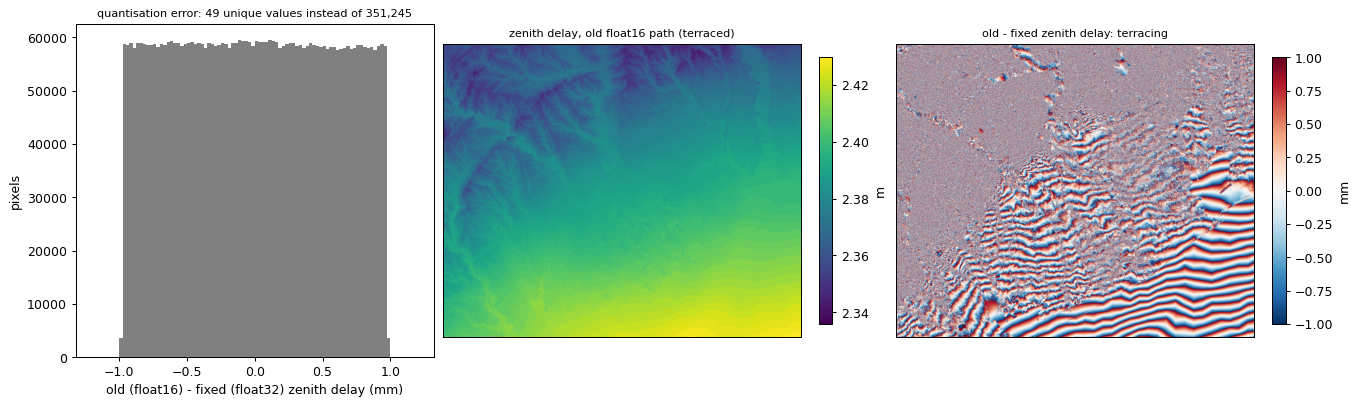

In [4]:
# Projection to LOS as in prepare_troposphere_correction (the layer the calibration receives is sec - ref)
los_ds = StaticLayer.from_path(los_file).to_dataset()
los_ds = los_ds.rio.write_crs(los_ds.attrs["crs_wkt"])
los_up = los_ds["los_up"].isel(y=slice(None, None, DEC), x=slice(None, None, DEC))
los_fixed = compute_los_correction(ztd_fixed, los_up)
los_old = compute_los_correction(ztd_old, los_up)
los_err_mm = (los_old.values - los_fixed.values) * 1e3
print(f"LOS delay: old - fixed max |err| {np.nanmax(np.abs(los_err_mm)):.2f} mm (one date);"
      f" the differential correction (sec - ref) combines two such errors, up to ±{2*np.nanmax(np.abs(los_err_mm)):.1f} mm")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)
axes[0].hist(err_mm[ok], bins=np.linspace(-1.2, 1.2, 97), color="0.5")
axes[0].set_xlabel("old (float16) - fixed (float32) zenith delay (mm)"); axes[0].set_ylabel("pixels")
axes[0].set_title(f"quantisation error: {u_old} unique values instead of {u_fixed:,}", fontsize=9)
im = axes[1].imshow(old_values, cmap="viridis")
axes[1].set_title("zenith delay, old float16 path (terraced)", fontsize=9)
fig.colorbar(im, ax=axes[1], shrink=0.8, label="m")
im = axes[2].imshow(err_mm, cmap="RdBu_r", vmin=-1, vmax=1)
axes[2].set_title("old - fixed zenith delay: terracing", fontsize=9)
fig.colorbar(im, ax=axes[2], shrink=0.8, label="mm")
for ax in axes[1:]:
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

zoom window rows 1050-1350, cols 1950-2250 (decimated grid)


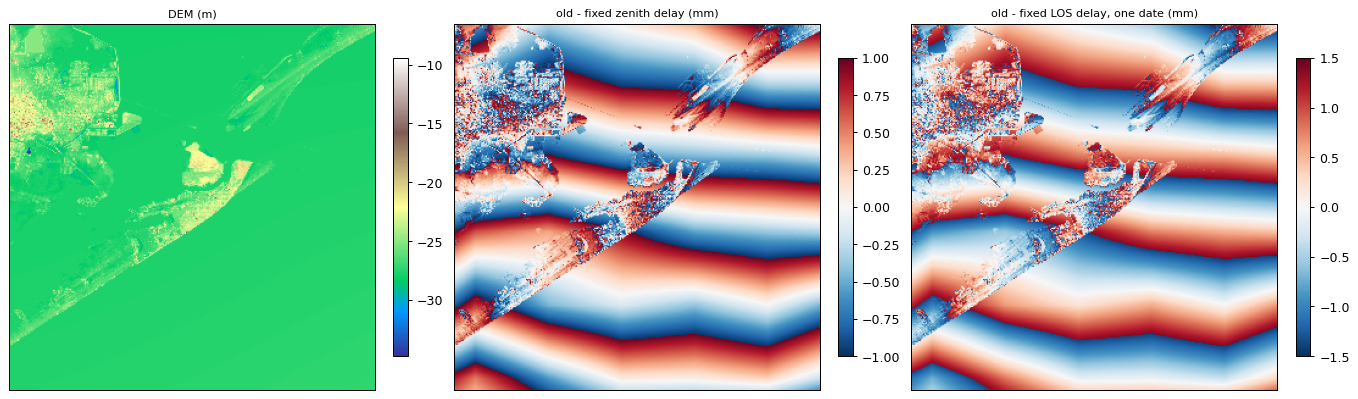

In [5]:
# Zoom (300 x 300 decimated pixels) on the smoothest-terrain window that lies fully inside the frame
# footprint: there the delay varies slowly, so the float16 steps show up as clean terraces
win = 300
rows = range(0, dem32.shape[0] - win, win // 2)
cols = range(0, dem32.shape[1] - win, win // 2)
inside = [(r, c) for r in rows for c in cols if np.isfinite(los_err_mm[r:r + win, c:c + win]).all()]
r0, c0 = min(inside, key=lambda rc: np.nanstd(dem32.values[rc[0]:rc[0] + win, rc[1]:rc[1] + win]))
sl = (slice(r0, r0 + win), slice(c0, c0 + win))
print(f"zoom window rows {r0}-{r0 + win}, cols {c0}-{c0 + win} (decimated grid)")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)
im = axes[0].imshow(dem32.values[sl], cmap="terrain"); axes[0].set_title("DEM (m)", fontsize=9)
fig.colorbar(im, ax=axes[0], shrink=0.8)
im = axes[1].imshow(err_mm[sl], cmap="RdBu_r", vmin=-1, vmax=1); axes[1].set_title("old - fixed zenith delay (mm)", fontsize=9)
fig.colorbar(im, ax=axes[1], shrink=0.8)
im = axes[2].imshow(los_err_mm[sl], cmap="RdBu_r", vmin=-1.5, vmax=1.5); axes[2].set_title("old - fixed LOS delay, one date (mm)", fontsize=9)
fig.colorbar(im, ax=axes[2], shrink=0.8)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.show()